# Language Structure and Transformers

In the last two weeks, we explored how to turn raw text into something a machine learning model can actually work with. We started with simple tools like **bag of words** and **TF-IDF** to count and weight words, and then trained classifiers to spot patterns (like spam detection). In Week 2, we stepped it up by using **spacy** for smarter tokenization and lemmatization, and we built pipelines to organize our code and make model training more streamlined.

This week, we’re shifting focus from "what words are in the text" to **how those words relate to each other**. We’ll use spacy to dig into the structure of language using:

- **Part of Speech (POS) tagging**, what grammatical role each word plays
- **Named Entity Recognition (NER)**, pulling out things like names, places, and dates

After that, we’ll try out a modern language model: **DistilBERT**, a transformer that understands language much more deeply than our earlier models. We'll use the Hugging Face `pipeline()` to get it working in just a few lines of code.

## Part of Speech Tagging (POS)

Part of speech tagging is the process of identifying the grammatical role of each word in a sentence, like whether it's a noun, verb, adjective, or something else. This is done based on the word's definition **and** the context it appears in.

That last part is important: POS tagging isn't just a dictionary lookup. Words can take on different roles depending on how they’re used. For example:

- *Your work will **bear** fruit.*  
- *A **bear** is chasing you.*

Same word, completely different meanings and parts of speech, one is a **verb**, the other a **noun**.

When we create a spacy object, it automatically runs a POS tagger on each token. You can access the result using the `.pos_` attribute of each token.

In [3]:
import spacy
nlp = spacy.load("en_core_web_sm")

doc = nlp("The bear will bear the burden.")

for token in doc:
    print(f"{token.text:<10} {token.pos_}")

The        DET
bear       NOUN
will       AUX
bear       VERB
the        DET
burden     NOUN
.          PUNCT


### Common POS Tags

| Tag       | Meaning                 | Example                 |
|-----------|--------------------------|--------------------------|
| `NOUN`    | Noun                     | dog, gift, prize         |
| `PROPN`   | Proper noun              | Walmart, Visa, Amazon    |
| `VERB`    | Verb                     | click, claim, win        |
| `ADJ`     | Adjective                | free, amazing, urgent    |
| `ADV`     | Adverb                   | now, quickly             |
| `PRON`    | Pronoun                  | you, we, I               |
| `DET`     | Determiner               | the, a, this             |

Visualizing the distribution of POS tags gives us insight into the grammatical structure of our text. For example, a sentence with lots of verbs might be action oriented, while one full of nouns might be more descriptive. These patterns can help us understand tone, purpose, or even distinguish between different types of messages (like spam vs. ham). It’s a simple but powerful way to treat language structure as part of our EDA.

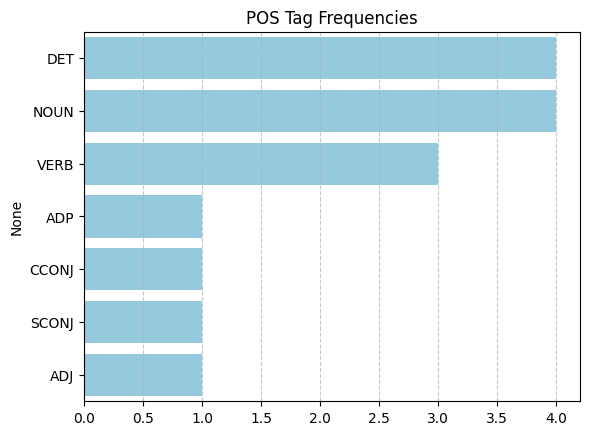

In [ ]:
import spacy
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

nlp = spacy.load("en_core_web_sm")
text = "Congratulations! You have WON a $1000 Walmart gift card! Click the link below to claim your prize now!"
doc = nlp(text)
pos_counts = pd.Series(token.pos_ for token in doc).value_counts()

plt.figure()
sns.barplot(y=pos_counts.index, x=pos_counts.values, color='skyblue')
plt.title("POS Tag Frequencies")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Can POS Tags Be Used in a Model?

Absolutely, POS tags can be useful features, especially in traditional machine learning models like logistic regression or decision trees. For example, spam messages might contain more verbs or proper nouns (like brand names), while ham messages might use more pronouns and conversational words.

We could extract features like:
- Number of verbs or adjectives
- Proportion of nouns in a message
- Specific POS patterns (VERB + NOUN)

These structural clues can help a model understand the **style** of a message, not just the words it contains. That said, modern transformer models (like BERT) don’t need POS tags, they learn these patterns internally through attention and context.


## Named Entity Recognition (NER)

Named Entity Recognition (NER) is another powerful form of **EDA**, but instead of focusing on the structure of language (like POS tags), it focuses on extracting **real world objects** mentioned in the text.

NER systems scan text to find and classify **named entities**:

- People (`PERSON`)
- Organizations (`ORG`)
- Locations (`GPE`)
- Dates, times, monetary amounts, and more

This is especially useful when we want to extract **who or what** a sentence is talking about. For example, in a dataset of tweets, news articles, or customer reviews, NER helps us answer:
> *Who is being mentioned? Are they talking about a company? A place? A person?*

### How It Works

When you run spacy's NER pipeline on a sentence, it uses a **pretrained model** that looks for:
- Capitalization
- Sentence context
- Word patterns
- Part of speech hints

It then tags spans of text as entities and assigns a category label.

In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm")

text = "Microsoft is working with NASA to send Gaben to the International Space Station in 2025."
doc = nlp(text)

for ent in doc.ents:
    print(ent.text, ent.label_)

Microsoft ORG
NASA ORG
Gaben ORG
the International Space Station ORG
2025 DATE


### NER Issues

NER is smart, but it's not perfect. You’ll probably notice that Geralt, Novigrad, and Dandelion aren’t detected, even though they should be people and places. Why?

spacy relies on:

    Training data (these are fictional names it’s never seen)
    Capitalization and sentence cues

Try rewriting it and see if spacy recognizes one or more of them as named entities. This shows how small changes in formatting and familiarity affect NER performance.

In [14]:
import spacy

nlp = spacy.load("en_core_web_sm")
doc = nlp("geralt is traveling to novigrad with dandelion. he met yennefer in velen in 1265.")

print(f"{'Token':<15} | {'Lemma':<15} | {'POS':<10} | {'NER':<10}\n")
for token in doc:
    ner = token.ent_type_ if token.ent_type_ else "—"
    print(f"{token.text:<15} | {token.lemma_:<15} | {token.pos_:<10} | {ner:<10}")

Token           | Lemma           | POS        | NER       

geralt          | geralt          | NOUN       | —         
is              | be              | AUX        | —         
traveling       | travel          | VERB       | —         
to              | to              | PART       | —         
novigrad        | novigrad        | NOUN       | —         
with            | with            | ADP        | —         
dandelion       | dandelion       | NOUN       | —         
.               | .               | PUNCT      | —         
he              | he              | PRON       | —         
met             | meet            | VERB       | —         
yennefer        | yennefer        | PROPN      | —         
in              | in              | ADP        | —         
velen           | velen           | NOUN       | —         
in              | in              | ADP        | —         
1265            | 1265            | NUM        | DATE      
.               | .               | PUN

### Can NER Tags Be Used in a Model?

Just like we explored with POS tags, we can also use NER results as features in a model. Spam messages often mention names, dates, money, or companies and these can be powerful clues. We can count how many named entities are in a message or flag if certain types (like MONEY or ORG) appear. These features can be combined with TF-IDF, POS, or other data to help a model make better predictions.


## Transformer Models with Hugging Face

So far, we’ve built our own NLP pipelines using tools like CountVectorizer, TF-IDF, and even added linguistic features like POS and NER to get a feel for how language works beyond just word counts. These tools gave us a glimpse of **context**, things like sentence structure, word roles, and named entities which help reveal what a sentence is really saying.

Now we’re going to see how modern NLP works using **transformers**, deep learning models that have been pretrained on huge corpora (Yes, "corpora" is the plural of "corpus") of text and can understand language far more deeply than traditional models.

We’ll use the **Hugging Face Transformers library**, which gives us access to models like **BERT** and **DistilBERT** with just a few lines of code. These models already understand grammar, context, and meaning, we just give them raw text, and they give us high quality predictions.

Unlike our TF-IDF based model, which only knows which words were common, BERT knows:
- What a word means **in context**
- How each word relates to others in the sentence
- The overall sentiment or intent behind a message

### Install Transformers

The first step is to install the transformers module using pip or Anaconda, you will need to run the following cell once to install the module in your environment.

In [ ]:
# !pip install torch --index-url https://download.pytorch.org/whl/cpu
# !pip install transformers

In [1]:
from transformers import pipeline

# Load a pretrained sentiment analysis pipeline
classifier = pipeline("sentiment-analysis",  model="distilbert/distilbert-base-uncased-finetuned-sst-2-english")

text = "I absolutely hated the new Witcher tv show!"
result = classifier(text)

print(result)

Device set to use cpu


[{'label': 'NEGATIVE', 'score': 0.999163031578064}]


### Different Models for Different Tasks

The model we used here is one of many models available on Hugging Face, here are a few more examples:

| Pipeline Task         | Example Model Name                                                  | What It Does                                                |
|-----------------------|---------------------------------------------------------------------|-------------------------------------------------------------|
| `"sentiment-analysis"`| `distilbert-base-uncased-finetuned-sst-2-english`                  | Detects if text expresses positive or negative emotion.     |
| `"text-generation"`   | `gpt2`                                                              | Continues a prompt by generating realistic-looking text.    |
| `"text-classification"`| `bert-base-uncased` (with fine-tuning)                            | Assigns one or more labels to a piece of text.              |
| `"question-answering"`| `distilbert-base-cased-distilled-squad`                            | Answers a question using a given context paragraph.         |
| `"translation"`       | `Helsinki-NLP/opus-mt-en-fr`                                       | Translates text from one language to another.               |
| `"summarization"`     | `facebook/bart-large-cnn`                                          | Condenses long passages into short summaries.               |

You can browse the [Hugging Face Model Hub](https://huggingface.co/models) to find models tailored to your task, language, and resource constraints.

## What's Happening Under the Hood?

Transformers may seem like magic, but under the hood they follow a predictable pipeline. Let’s walk through the key steps:

### Tokens

The first step is breaking your input text into smaller units called **tokens**. These tokens are often full words, but they can also be **subwords**, pieces of words that are reused across different terms. This allows the model to handle **unfamiliar or rare words** by decomposing them into known parts.

**Example:**  
The word `"unbelievable"` might be split into:  
`["un", "believ", "able"]`

### Embeddings

Each token is converted into a **vector of numbers** that represents its meaning. These vectors are known as **embeddings**. At this stage, we’re not too far from earlier techniques like **TF-IDF**, we’re still turning words into numbers.

### Self Attention

This is the core innovation of transformers.

Instead of processing each word independently, the model looks at **all tokens at once** and calculates how much **each word should pay attention to every other word** in the sentence.

**Example:**  
In the sentence: *"The bank raised interest rates."*  
The model gives strong attention between:
- `"bank"` and `"interest"`  
- `"raised"` and `"rates"`

These connections help it understand that “bank” is probably a **financial institution**, not a riverbank. This happens for **every word**, meaning every token is constantly being reinterpreted in light of its neighbors.

### Layers of Understanding

Transformers apply this self attention process **repeatedly**, across multiple **stacked layers**.

Each layer:
- Computes self attention
- Refines the meaning of each word
- Passes the updated vectors to the next layer

You can think of each layer like reading the sentence again with more insight.

- **First layer**: Picks up simple relationships  
- **Later layers**: Capture deeper structure, nuance, and intent

# Summary

This week, we shifted our focus from surface level text processing (like Bag of Words and TF-IDF) to **deeper, contextual understanding** using modern NLP tools. Here's what we covered:

## Part of Speech Tagging (POS)

- We used **spacy** to identify the grammatical role of each word (noun, verb, adjective, etc.).
- POS tagging gives us insight into sentence structure, which can help:
  - Detect patterns in writing
  - Analyze sentence complexity
  - Build features for classic models

## Named Entity Recognition (NER)

- Next we explored how to automatically detect **people, places, organizations, dates**, and other named entities in a text.
- NER is useful for:
  - Information extraction
  - Summarizing documents
  - Tagging and searching corpora
  - Build features for classic models

## Transformers & Hugging Face

- Hugging Face’s `pipeline()` makes it easy to run complex models with minimal setup
- Under the hood, transformers use:
  - Tokenization
  - Embeddings
  - Self attention
  - Layers